In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



data = pd.read_csv('Data/train_cleaned.csv', index_col='Id')
y = data['SalePrice']
X = data.drop('SalePrice', axis = 1)

X

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,True,False,False,False,False,False,False,False,False,True
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,True,False,False,False,False,False,False,False,False,True
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,True,False,False,False,False,False,False,False,False,True
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,True,False,False,False,False,False,False,False,False,True
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,True,False,False,False,False,False,False,False,False,True
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,True,False,False,False,False,False,False,False,False,True
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,True,False,False,False,False,False,False,False,False,True


# Exploratory Data Analysis
with `SalesPrice` as a target value. Begin with analyzing target and data structure, then splitting data into binary, ordinal and numerical.

## Target analysis

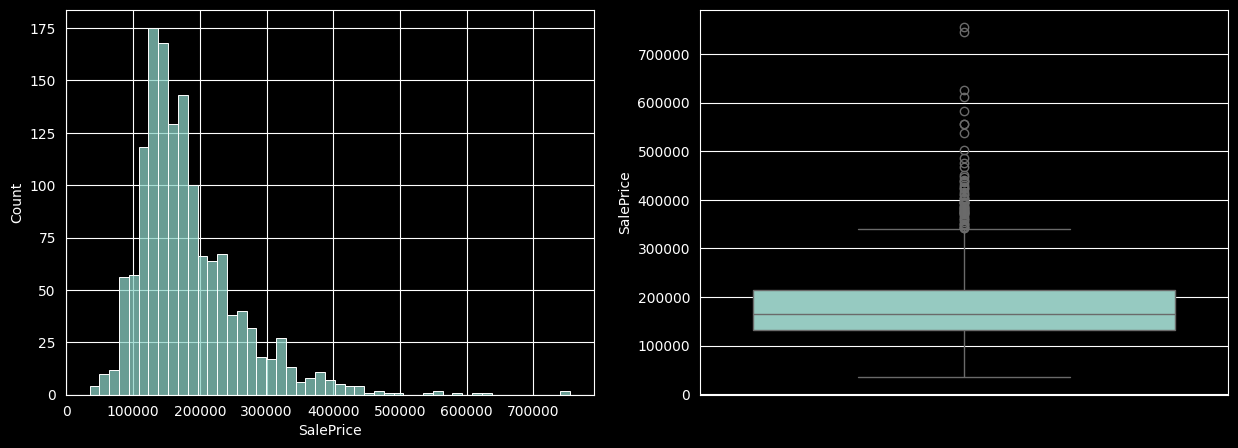

,0
mean,182507.021955
std,79270.416057


In [13]:
target = data['SalePrice']

fig, ax  = plt.subplots(1,2, figsize = (15,5))
ax = ax.flatten()

sns.histplot(target,ax=ax[0])
sns.boxplot(target,ax=ax[1])

plt.show()

target_info = pd.DataFrame.from_dict({"mean": target.mean(), "std": target.std()}, orient='index')
target_info

### Test for normality

In [16]:
from scipy import stats

print("--- Normality Test (Shapiro-Wilk) ---")
# The Shapiro-Wilk test is the standard for checking normality.
# Null Hypothesis (H0): The data is normally distributed.
shapiro_stat, shapiro_p = stats.shapiro(target)

print(f"Shapiro-Wilk Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Result: Data looks Gaussian (Normal). We fail to reject the null hypothesis.")
else:
    print("Result: Data does not look Gaussian. We reject the null hypothesis.")


--- Normality Test (Shapiro-Wilk) ---
Shapiro-Wilk Statistic: 0.8680
P-value: 0.0000
Result: Data does not look Gaussian. We reject the null hypothesis.


## Outliers

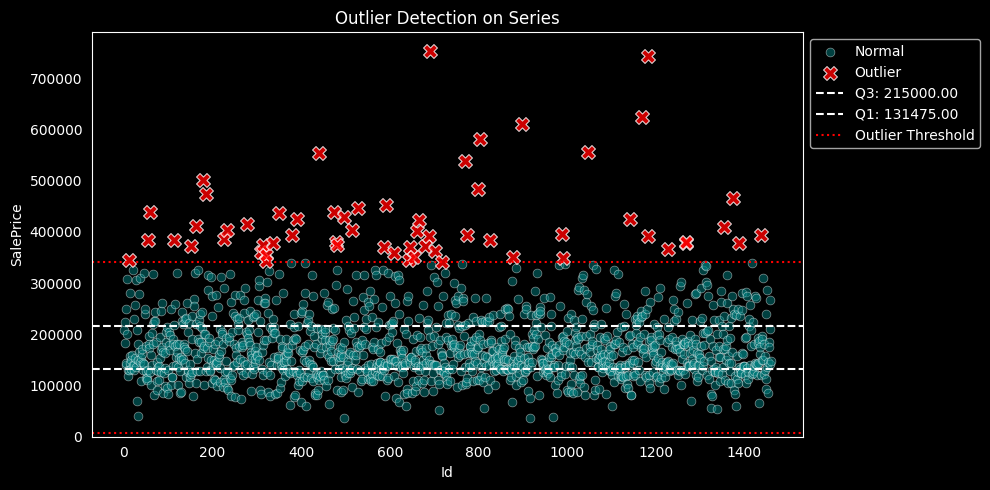

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'target' is your pandas Series
# target = pd.Series(...)

# 1. Calculate IQR and Bounds
q1 = target.quantile(0.25)
q3 = target.quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + (1.5 * iqr)
lower_bound = q1 - (1.5 * iqr)


is_outlier = (target > upper_bound) | (target < lower_bound)


fig, ax = plt.subplots(figsize=(10, 5))


sns.scatterplot(x=target[~is_outlier].index,
                y=target[~is_outlier],
                ax=ax, label="Normal", color='teal', s=40, alpha=0.5)


sns.scatterplot(x=target[is_outlier].index,
                y=target[is_outlier],
                ax=ax, label="Outlier", color='red', marker='X', s=100, alpha=0.8)


ax.axhline(q3, color='white', linestyle='--', alpha=1, label=f'Q3: {q3:.2f}')
ax.axhline(q1, color='white', linestyle='--', alpha=1, label=f'Q1: {q1:.2f}')
ax.axhline(upper_bound, color='red', linestyle=':', alpha=1, label='Outlier Threshold')
ax.axhline(lower_bound, color='red', linestyle=':', alpha=1)

# Formatting
ax.set_title("Outlier Detection on Series")
ax.legend(bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
ax.grid(False)
plt.show()

In [28]:
outliers_info = pd.DataFrame.from_dict({"count": target[is_outlier].count(), "percent": target[is_outlier].count()/target.count()}, orient='index')

outliers_info

,0
count,60.000000
percent,0.042493


# Data Structure

In [58]:
data_without_target = data.drop('SalePrice', axis = 1)
data_without_target = data_without_target[data_without_target.dtypes.sort_values().index]

data_without_target.iloc[:, 111:]
print(data_without_target.iloc[:, 111:].columns)

Index(['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'GarageCars',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'HalfBath', 'GrLivArea', 'BsmtFinSF2', '2ndFlrSF', '1stFlrSF',
       'TotalBsmtSF', 'BsmtUnfSF', 'BsmtFinSF1', 'YearRemodAdd', 'YearBuilt',
       'OverallCond', 'OverallQual', 'LotArea', 'GarageArea', 'LowQualFinSF',
       'WoodDeckSF', 'HeatingQC', 'EnclosedPorch', 'OverallQual.1',
       'SaleCondition', 'LandContour', 'LotShape', 'LandSlope', 'GarageFinish',
       'BsmtExposure', 'BsmtFinType2', 'BsmtFinType1', 'GarageCond',
       'OpenPorchSF', 'GarageQual', 'KitchenQual', 'BsmtCond', 'BsmtQual',
       'ExterCond', 'ExterQual', 'YrSold', 'MoSold', 'MiscVal', 'PoolArea',
       'ScreenPorch', '3SsnPorch', 'FireplaceQu', 'MSSubClass', 'MasVnrArea',
       'LotFrontage'],
      dtype='object')


In [54]:
data_without_target.dtypes.value_counts()

bool       111
int64       51
float64      2
Name: count, dtype: int64

In [33]:
data_without_target.shape

(1412, 164)

# Different Kinds of Features

In [68]:
binary_data = data_without_target.iloc[:, 0:111]

ordinal_col = [
    'OverallQual', 'OverallQual.1', 'OverallCond', 'MSSubClass',
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual',
    'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond',
    'LotShape', 'LandSlope', 'LandContour', 'SaleCondition'
]
ordinal_data = data_without_target.loc[:, ordinal_col]

date_time_col = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'MoSold']
date_time_data = data_without_target.loc[:, date_time_col]

numerical_col = [
    'GrLivArea', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF', 'BsmtUnfSF',
    'BsmtFinSF1', 'BsmtFinSF2', 'LotArea', 'LotFrontage', 'GarageArea',
    'MasVnrArea', 'PoolArea', 'ScreenPorch', '3SsnPorch', 'EnclosedPorch',
    'OpenPorchSF', 'WoodDeckSF', 'LowQualFinSF', 'MiscVal',
    'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars'
]
num_data = data_without_target.loc[:, numerical_col]

b_count = binary_data.shape[1]
o_count = ordinal_data.shape[1]
d_count = date_time_data.shape[1]
n_count = num_data.shape[1]
sum = b_count + o_count + d_count + n_count

data_count = pd.DataFrame.from_dict(
    {"binary": b_count, "ordinal": o_count, "data_time": d_count, "numerical": n_count, "sum": sum,
     "should be": data_without_target.shape[1]}, orient='index'
)

data_count

,0
binary,111
ordinal,21
data_time,4
numerical,28
sum,164
should be,164
